In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [3]:
df = pd.read_csv("C:\Loan-Default-Prediction\data\loan_data.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
print(df.head())
print(df.tail())
print(df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print(df.dtypes)
print(df.info())
print(df.describe())

df.isnull().sum()

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [5]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()
print(df.shape)

Duplicate rows: 0
(614, 13)


In [6]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [7]:
categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Self_Employed"
]

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [9]:
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())

df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(
    df["Loan_Amount_Term"].median()
)

df["Credit_History"] = df["Credit_History"].fillna(
    df["Credit_History"].mode()[0]
)

In [10]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [11]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,145.752443,342.410423,0.855049
std,6109.041673,2926.248369,84.107233,64.428629,0.352339
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2877.500000,0.000000,100.250000,360.000000,1.000000
50%,3812.500000,1188.500000,128.000000,360.000000,1.000000
75%,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


In [12]:
df = df.dropna(subset=["Loan_Status"])

In [13]:
df["Gender"] = df["Gender"].map({
    "Male": 1,
    "Female": 0
})

df["Married"] = df["Married"].map({
    "Yes": 1,
    "No": 0
})

df["Education"] = df["Education"].map({
    "Graduate": 1,
    "Not Graduate": 0
})

df["Self_Employed"] = df["Self_Employed"].map({
    "Yes": 1,
    "No": 0
})

df["Dependents"] = df["Dependents"].replace("3+", 3).astype(int)

df["Property_Area"] = df["Property_Area"].map({
    "Rural": 0,
    "Semiurban": 1,
    "Urban": 2
})

df["Loan_Status"] = df["Loan_Status"].map({
    "N": 0,
    "Y": 1
})

In [14]:
features = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History",
    "Property_Area"
]

X = df[features]
y = df["Loan_Status"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [16]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
y_pred = model.predict(X_test)

In [18]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7723577235772358

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.42      0.56        43
           1       0.75      0.96      0.85        80

    accuracy                           0.77       123
   macro avg       0.81      0.69      0.70       123
weighted avg       0.79      0.77      0.75       123



In [19]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
9,Credit_History,0.260142
5,ApplicantIncome,0.209382
7,LoanAmount,0.184596
6,CoapplicantIncome,0.110666
8,Loan_Amount_Term,0.054260
10,Property_Area,0.048448
2,Dependents,0.046685
1,Married,0.024484
3,Education,0.021985
0,Gender,0.020841


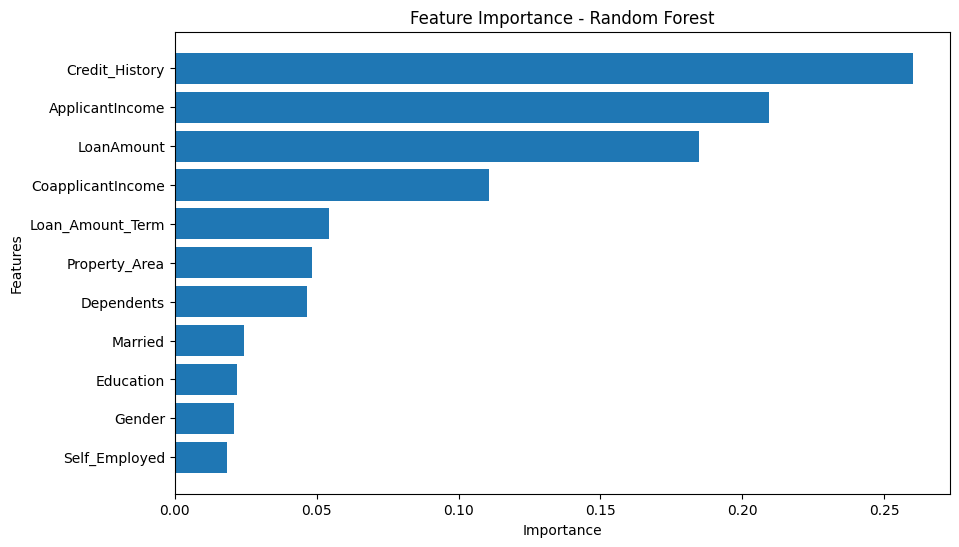

In [20]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Random Forest")

plt.gca().invert_yaxis()

plt.show()

In [21]:
joblib.dump(model, "loan_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [22]:
loaded_model = joblib.load("loan_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [23]:
sample = [[
    1,      # Gender
    1,      # Married
    1,      # Dependents
    1,      # Education
    0,      # Self Employed
    5000,   # Applicant Income
    1500,   # Coapplicant Income
    150,    # Loan Amount
    360,    # Loan Amount Term
    1,      # Credit History
    2       # Property Area
]]

prediction = loaded_model.predict(sample)

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Rejected")

Loan Approved


c:\Loan-Default-Prediction\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
